# Decision Trees as Interpretable Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

# *Obtain Data*

In [2]:
columns = ['temperature', 'nausea', 'lumbar-pain', 'urine-pushing', 'micturition-pains', 'burning-urethra', 'bladder-inflammation', 'nephritis']
diagnosis_df = pd.read_csv('../data/diagnosis.data', names=columns, header=None, delim_whitespace=True, encoding='utf-16')
diagnosis_df['temperature'] = diagnosis_df['temperature'].str.replace(',', '.').astype(float)

for categorical_column in columns[1:]:
    diagnosis_df[categorical_column] = diagnosis_df[categorical_column].map({'yes': 1, 'no': 0})

diagnosis_df

,temperature,nausea,lumbar-pain,urine-pushing,micturition-pains,burning-urethra,bladder-inflammation,nephritis
0,35.5,0,1,0,0,0,0,0
1,35.9,0,0,1,1,1,1,0
2,35.9,0,1,0,0,0,0,0
3,36.0,0,0,1,1,1,1,0
4,36.0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
115,41.4,0,1,1,0,1,0,1
116,41.5,0,0,0,0,0,0,0
117,41.5,1,1,0,1,0,0,1
118,41.5,0,1,1,0,1,0,1


# *Build a decision tree*

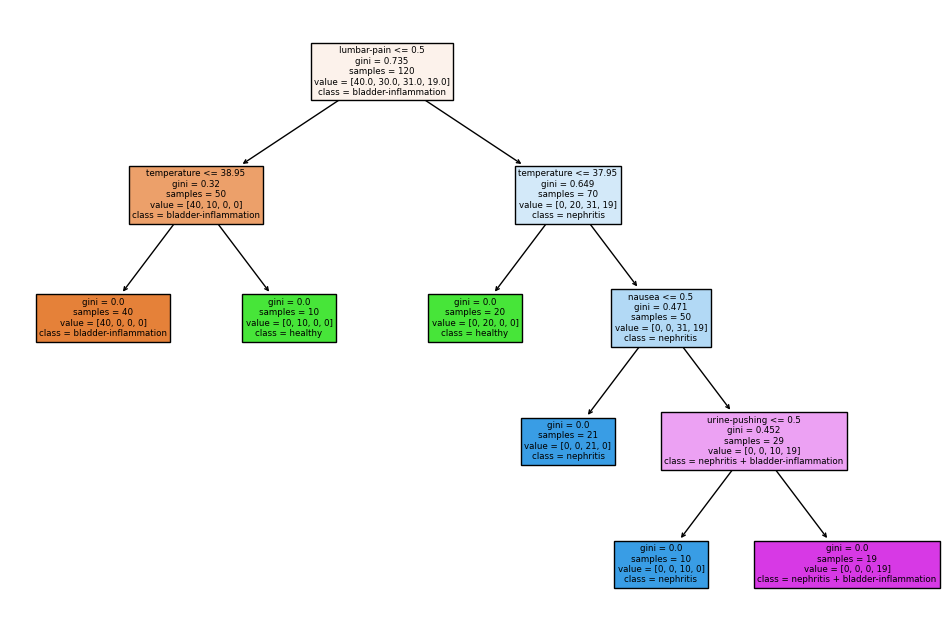

In [3]:
target_df = diagnosis_df.iloc[:, -2:]
target_df['bit_encoding'] = target_df['bladder-inflammation'].astype(str) + target_df['nephritis'].astype(str)
mapping = {'00': 'healthy', '01': 'nephritis', '10': 'bladder-inflammation', '11': 'nephritis + bladder-inflammation'}
target_df['combined_class'] = target_df['bit_encoding'].map(mapping)

X = diagnosis_df.iloc[:, :-2]
y = target_df.iloc[:, -1] 

tree = DecisionTreeClassifier(random_state=24)
tree.fit(X,y)

plt.figure(figsize=(12, 8))
plot_tree(tree, filled=True, feature_names=X.columns, class_names=np.unique(y.values))
plt.show()

# *Convert the decision rules*

In [4]:
tree_rules = export_text(tree, feature_names=list(X.columns))
print(tree_rules)

|--- lumbar-pain <= 0.50
|   |--- temperature <= 38.95
|   |   |--- class: bladder-inflammation
|   |--- temperature >  38.95
|   |   |--- class: healthy
|--- lumbar-pain >  0.50
|   |--- temperature <= 37.95
|   |   |--- class: healthy
|   |--- temperature >  37.95
|   |   |--- nausea <= 0.50
|   |   |   |--- class: nephritis
|   |   |--- nausea >  0.50
|   |   |   |--- urine-pushing <= 0.50
|   |   |   |   |--- class: nephritis
|   |   |   |--- urine-pushing >  0.50
|   |   |   |   |--- class: nephritis + bladder-inflammation



In [5]:
def convert_rules(tree_rules): 
    
    lines = tree_rules.split('\n')
    rule = []
    all_rules = []
    root_condition = ''
    
    for line in lines:
        depth = line.count('|')
        stripped_line = line.replace('|--- ', '').replace('|', '').strip()

        if depth == 1:
            rule = []
            root_condition = stripped_line
            rule.append(root_condition)

        elif "class:" in stripped_line:
            class_name = stripped_line.split(": ")[1]
            condition = " AND ".join(rule)
            all_rules.append(f"IF {condition} THEN {class_name}")
            rule = rule[:depth]

        else:
            condition = stripped_line
            rule = rule[:depth - 1]  
            rule.append(condition)

    return "\n".join(all_rules)

        
print(convert_rules(tree_rules))

IF lumbar-pain <= 0.50 AND temperature <= 38.95 THEN bladder-inflammation
IF lumbar-pain <= 0.50 AND temperature >  38.95 THEN healthy
IF lumbar-pain >  0.50 AND temperature <= 37.95 THEN healthy
IF lumbar-pain >  0.50 AND temperature >  37.95 AND nausea <= 0.50 THEN nephritis
IF lumbar-pain >  0.50 AND temperature >  37.95 AND nausea >  0.50 AND urine-pushing <= 0.50 THEN nephritis
IF lumbar-pain >  0.50 AND temperature >  37.95 AND nausea >  0.50 AND urine-pushing >  0.50 THEN nephritis + bladder-inflammation


# *Cost-complexity pruning*

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
model = DecisionTreeClassifier(random_state=24)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.09908537 0.12152778 0.15792495 0.248288  ]


In [7]:
kfold = KFold(n_splits=5, shuffle=True, random_state=24)
alphas = np.arange(0, 0.275, 0.025)
scores = {alpha: [] for alpha in alphas} 

for train_index, val_index in kfold.split(X, y):
    
    X_train, X_val = X.iloc[train_index, :], X.iloc[val_index, :]
    y_train, y_val = y[train_index], y[val_index]

    for alpha in alphas:
        model = DecisionTreeClassifier(random_state=24, ccp_alpha=alpha)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        scores[alpha].append(accuracy)
                 
average_scores = {alpha: np.mean(score_list) for alpha, score_list in scores.items()}
average_scores_df = pd.DataFrame({'Alpha': [alpha for alpha in scores.keys()], 'Mean Accuracy': [mean_score for mean_score in average_scores.values()]})
average_scores_df

,Alpha,Mean Accuracy
0,0.000,0.983333
1,0.025,0.983333
2,0.050,0.983333
3,0.075,0.983333
4,0.100,0.866667
5,0.125,0.775000
6,0.150,0.750000
7,0.175,0.625000
8,0.200,0.583333
9,0.225,0.500000


We can see from the above cross-validation results that we can prune the tree up to an alpha value of 0.075 before we start to see performance begin to decrease. Thus, to find the minimum-pruned tree we should use an alpha of 0.1.  

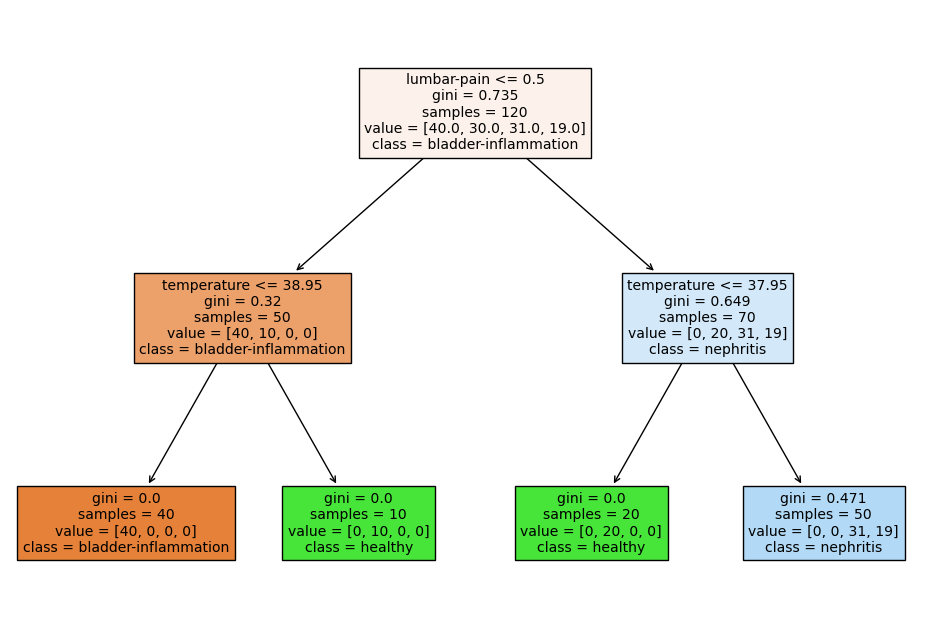

In [8]:
pruned_tree = DecisionTreeClassifier(random_state=24, ccp_alpha=0.1)
pruned_tree.fit(X,y)

plt.figure(figsize=(12, 8))
plot_tree(pruned_tree, filled=True, feature_names=X.columns, class_names=np.unique(y.values))
plt.show()

In [9]:
pruned_tree_rules = export_text(pruned_tree, feature_names=list(X.columns))
print(convert_rules(pruned_tree_rules))

IF lumbar-pain <= 0.50 AND temperature <= 38.95 THEN bladder-inflammation
IF lumbar-pain <= 0.50 AND temperature >  38.95 THEN healthy
IF lumbar-pain >  0.50 AND temperature <= 37.95 THEN healthy
IF lumbar-pain >  0.50 AND temperature >  37.95 THEN nephritis


One thing to note is that when we find the minimum-pruned decision tree above, we lose the ability to classify the 'nephritis + bladder-inflammation' class. Thus, in this case pruning the tree might not be the best idea. 